# Team Challenge · Sprint 03-04 - Catálogo de películas

**Dataset:**  
- [movies.csv](./data/movies.csv)
- [ratings.csv](./data/ratings.csv)
- [tags.csv](./data/tags.csv)
- [links.csv](./data/links.csv) 

**Entregables:** Repositorio de GitHub con el código fuente. Puede ser scripts de python o notebook ordenado, código reproducible, README con cómo ejecutar el proyecto.

**Control de versiones:** gestión del proyecto con **GitHub desde el primer día**. Trabajar en equipo en paralelo con **ramas**, **pull requests** y revisión entre compañeros.

**Parte 1 (Pandas):** Data analytics (Pandas)

**Parte 2 (TMDB):** una petición `GET /3/movie/{id}` por película; definid `TMDB_API_KEY` o `TMDB_READ_ACCESS_TOKEN` en el entorno (sin subir claves al repo).

**Parte 3 (Gemini):** añadir `overview_es` a `movies10` a partir de los `overview` de TMDB; definid `GEMINI_API_KEY` o usad `getpass` (sin subir claves al repo). Requiere `pip install google-genai`.

**Parte 4 (opcional):**
- **A)** catálogo ampliado (`pitch_es`, `edad_sugerida`, `temas`).
- **B)** recomendador por género.

## Trabajo en equipo y control de versiones

- Crear el **repositorio en GitHub** al inicio (día 1–2), no al final.
- Definir una rama principal (`main`) y una para desarrollo (`develop`) y ramas por tarea (p. ej. `feature/parte1-pandas`, `feature/tmdb`, `feature/gemini`).
- Integrar el trabajo con **pull requests** hacia `develop`; al menos **una PR revisada y mergeada por miembro** del equipo.
- Evitar trabajar en en `main` es la rama de "producción"
- Resolver conflictos en ramas antes del merge.
- **README:** cómo clonar el repo, instalar dependencias, configurar claves (`TMDB_*`, `GEMINI_API_KEY`) y ejecutar el notebook o scripts.
- **No subir claves** al repositorio (usar `.gitignore` para `.env` si aplica).

## Parte 1: Data analytics (Pandas)

### 1. Ingesta de datos

- Los CSV están en **`Team_Challenges/TC_01_Sprint_03_04/data/`**.
- Cargar con **Pandas** los cuatro ficheros: `movies.csv`, `ratings.csv`, `tags.csv`, `links.csv`.
- Comprobar para cada `DataFrame`: `shape`, columnas, `dtypes`, `head` y conteo de nulos.

In [1]:
import pandas as pd

In [5]:
ruta_carpeta = r"C:/TheBridge/Copia_Original-Yordanos-Bootcamp  TheBridge/bootcamp_AI_Engineering_05_26/Team_Challenges/TC_01_Sprint_03_04/data/"

# Cargo el archivo de películas uniendo la ruta y el nombre del archivo
peliculas = pd.read_csv(ruta_carpeta + "movies.csv")

# Pongo un mensaje para saber que todo ha funcionado
print("¡Archivo de películas cargado con éxito!")

# Usamos la ruta que ya sabemos que funciona para cargar los 4 archivos
peliculas = pd.read_csv(ruta_carpeta + "movies.csv")
votos     = pd.read_csv(ruta_carpeta + "ratings.csv")
etiquetas = pd.read_csv(ruta_carpeta + "tags.csv")
enlaces   = pd.read_csv(ruta_carpeta + "links.csv")

print("¡Los 4 archivos se han cargado correctamente en la memoria!")

¡Archivo de películas cargado con éxito!
¡Los 4 archivos se han cargado correctamente en la memoria!


In [7]:

# 1. CHEQUEO DE PELÍCULAS
print(" ANALIZANDO: PELÍCULAS")
print("• Tamaño (Filas, Columnas):", peliculas.shape)
print("• Columnas:", list(peliculas.columns))
print("\n• Tipos de datos:\n", peliculas.dtypes)
print("\n• Valores vacíos (Nulos):\n", peliculas.isnull().sum())
print("\n• Vista previa:")
display(peliculas.head(3))
print("\n" + "="*50 + "\n")


# 2. CHEQUEO DE VOTOS
print("ANALIZANDO: VOTOS")
print("• Tamaño (Filas, Columnas):", votos.shape)
print("• Columnas:", list(votos.columns))
print("\n• Tipos de datos:\n", votos.dtypes)
print("\n• Valores vacíos (Nulos):\n", votos.isnull().sum())
print("\n• Vista previa:")
display(votos.head(3))
print("\n" + "="*50 + "\n")


# 3. CHEQUEO DE ETIQUETAS
print("ANALIZANDO: ETIQUETAS")
print("• Tamaño (Filas, Columnas):", etiquetas.shape)
print("• Columnas:", list(etiquetas.columns))
print("\n• Tipos de datos:\n", etiquetas.dtypes)
print("\n• Valores vacíos (Nulos):\n", etiquetas.isnull().sum())
print("\n• Vista previa:")
display(etiquetas.head(3))
print("\n" + "="*50 + "\n")


# 4. CHEQUEO DE ENLACES
print(" ANALIZANDO: ENLACES ")
print("• Tamaño (Filas, Columnas):", enlaces.shape)
print("• Columnas:", list(enlaces.columns))
print("\n• Tipos de datos:\n", enlaces.dtypes)
print("\n• Valores vacíos (Nulos):\n", enlaces.isnull().sum())
print("\n• Vista previa:")
display(enlaces.head(3))

 ANALIZANDO: PELÍCULAS
• Tamaño (Filas, Columnas): (9742, 3)
• Columnas: ['movieId', 'title', 'genres']

• Tipos de datos:
 movieId    int64
title        str
genres       str
dtype: object

• Valores vacíos (Nulos):
 movieId    0
title      0
genres     0
dtype: int64

• Vista previa:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance




ANALIZANDO: VOTOS
• Tamaño (Filas, Columnas): (100836, 4)
• Columnas: ['userId', 'movieId', 'rating', 'timestamp']

• Tipos de datos:
 userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

• Valores vacíos (Nulos):
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

• Vista previa:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224




ANALIZANDO: ETIQUETAS
• Tamaño (Filas, Columnas): (3683, 4)
• Columnas: ['userId', 'movieId', 'tag', 'timestamp']

• Tipos de datos:
 userId       int64
movieId      int64
tag            str
timestamp    int64
dtype: object

• Valores vacíos (Nulos):
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

• Vista previa:


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992




 ANALIZANDO: ENLACES 
• Tamaño (Filas, Columnas): (9742, 3)
• Columnas: ['movieId', 'imdbId', 'tmdbId']

• Tipos de datos:
 movieId      int64
imdbId       int64
tmdbId     float64
dtype: object

• Valores vacíos (Nulos):
 movieId    0
imdbId     0
tmdbId     8
dtype: int64

• Vista previa:


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0


### 2. Columna `year` desde el título

- En el dataset de películas. el año de estreno suele aparecer **entre paréntesis al final** de `title`, p. ej. `Batman (1989)`.
- Implementad una función (`year_from_title`) que devuelva un entero de cuatro cifras o valor ausente (`NaN` / `<NA>`) si el título no sigue ese patrón.
- Añadid la columna **`year`** a `movies` como numérico (`pd.to_numeric(..., errors="coerce")`).
- Editar el campo `title` para que no contenga el año de estreno.
- Contad cuántas películas **no** tienen año reconocible y mostrad **una pequeña muestra** de sus títulos (casos límite).

In [8]:
import re
import numpy as np

def year_from_title(titulo):
    if not isinstance(titulo, str):
        return np.nan
    
    patron = r"\((\d{4})\)\s*$"
    resultado = re.search(patron, titulo)

    if resultado:
        return resultado.group(1)
    else:

        return np.nan

In [9]:
peliculas['year'] = peliculas['title'].apply(year_from_title)

peliculas['year'] = pd.to_numeric(peliculas['year'], errors="coerce")

In [10]:
peliculas['title'] = peliculas['title'].str.replace(r"\(\d{4}\)\s*$", "", regex=True).str.strip()

In [11]:
sin_anio = peliculas[peliculas['year'].isna()]

print(f"Cantidad de películas sin año reconocible: {len(sin_anio)}")

print("\nMuestra de películas sin año reconocible:")
display(sin_anio[['title', 'genres']].head(10))

Cantidad de películas sin año reconocible: 13

Muestra de películas sin año reconocible:


,title,genres
6059,Babylon 5,Sci-Fi
9031,Ready Player One,Action|Sci-Fi|Thriller
9091,Hyena Road,(no genres listed)
9138,The Adventures of Sherlock Holmes and Doctor W...,(no genres listed)
9179,Nocturnal Animals,Drama|Thriller
9259,Paterson,(no genres listed)
9367,Moonlight,Drama
9448,The OA,(no genres listed)
9514,Cosmos,(no genres listed)
9515,Maria Bamford: Old Baby,(no genres listed)


### 2. Unificación de datos (*merge* / *join*)

- Entender las **claves** entre tablas (p. ej. `movieId` une `movies`, `ratings`, `tags` y `links`).
- Construir un esquema unificado: al menos una tabla **película–usuario–rating** (ratings enriquecida con título y géneros) y otra con **película–tags** si procede.
- Usar `merge` (u operaciones equivalentes) con criterio claro: tipo de unión (*inner* / *left*), duplicados generados y cómo se resuelven.
- Imprimir las 10 primeras filas de las tablas resultantes.
- Dejar documentado qué filas se pierden o se multiplican al unir y **por qué** es aceptable en vuestro caso de uso.

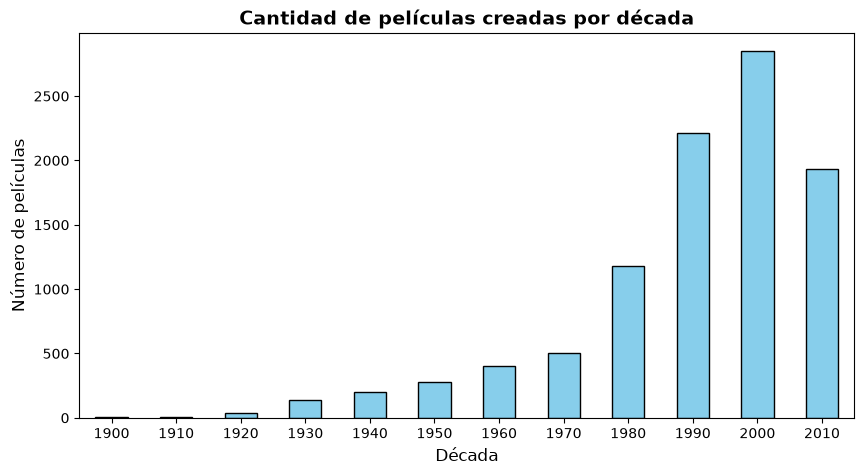

      VISTA PREVIA DE LA TABLA FINAL     


,title,year,decade
0,Toy Story,1995.0,1990
1,Jumanji,1995.0,1990
2,Grumpier Old Men,1995.0,1990
3,Waiting to Exhale,1995.0,1990
4,Father of the Bride Part II,1995.0,1990
5,Heat,1995.0,1990
6,Sabrina,1995.0,1990
7,Tom and Huck,1995.0,1990
8,Sudden Death,1995.0,1990
9,GoldenEye,1995.0,1990


In [19]:
import matplotlib.pyplot as plt

peliculas['decade'] = (peliculas['year'] // 10) * 10

peliculas['decade'] = peliculas['decade'].astype('Int64')

peliculas_por_decada = peliculas['decade'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
peliculas_por_decada.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Cantidad de películas creadas por década", fontsize=14, fontweight='bold')
plt.xlabel("Década", fontsize=12)
plt.ylabel("Número de películas", fontsize=12)
plt.xticks(rotation=0)

plt.show()

print("      VISTA PREVIA DE LA TABLA FINAL     ")
display(peliculas[['title', 'year', 'decade']].head(10))

### 4. Agregaciones y segmentación

- Usar `groupby` (por usuario, por película o por género) con al menos una agregación multi-columna (`agg`).
- Comparar dos segmentos (p. ej. usuarios con muchas valoraciones vs. pocos; o por **década** usando la columna `year` del apartado 3) con tablas resumen.

In [23]:
import pandas as pd

votos_detallados = pd.merge(votos, peliculas, on="movieId", how="left")

resumen_peliculas = votos_detallados.groupby("title").agg(
    total_valoraciones=("rating", "count"),
    nota_media=("rating", "mean")
).reset_index()

print(" RESUMEN DE VALORACIONES POR PELÍCULA")
display(resumen_peliculas.head(10))

def segmentar_por_epoca(anio):
    if pd.isna(anio):
        return "Sin Año"
    elif anio < 2000:
        return "Antigua (Siglo XX - Antes del 2000)"
    else:
        return "Moderna (Siglo XXI - Año 2000 o después)"

votos_detallados["epoca_pelicula"] = votos_detallados["year"].apply(segmentar_por_epoca)

comparativa_epocas = votos_detallados.groupby("epoca_pelicula").agg(
    total_votos_recibidos=("rating", "count"),
    nota_media_del_segmento=("rating", "mean")
).reset_index()

print(" COMPARATIVA: PELÍCULAS ANTIGUAS VS MODERNAS")
display(comparativa_epocas)

 RESUMEN DE VALORACIONES POR PELÍCULA


,title,total_valoraciones,nota_media
0,'71,1,4.000000
1,'Hellboy': The Seeds of Creation,1,4.000000
2,'Round Midnight,2,3.500000
3,'Salem's Lot,1,5.000000
4,'Til There Was You,2,4.000000
5,'Tis the Season for Love,1,1.500000
6,"'burbs, The",17,3.176471
7,'night Mother,1,3.000000
8,(500) Days of Summer,42,3.666667
9,*batteries not included,7,3.285714


 COMPARATIVA: PELÍCULAS ANTIGUAS VS MODERNAS


,epoca_pelicula,total_votos_recibidos,nota_media_del_segmento
0,Antigua (Siglo XX - Antes del 2000),61565,3.520799
1,Moderna (Siglo XXI - Año 2000 o después),39253,3.471314
2,Sin Año,18,3.638889


### 5. Preguntas sobre los datos (`movies`)

**Requisito:** haber creado la columna `year` en el **apartado 2**.

1. **Cuántas** películas están listadas en `movies`.
2. **Cuáles** son las **más antiguas** (menor año extraído del título).
3. **Cuántas** tienen **"Dracula"** en el título (coincidencia parcial, sin distinguir mayúsculas).
4. **Títulos más comunes**.
5. Películas con **"Exorcist"** ordenadas de la más antigua a la más moderna.
6. **Cuántas** con año **1950**.
7. **Cuántas** entre **1950 y 1959** inclusive.
8. **Año** de la película con título exacto **`Batman`** (y contraste con otras *Batman*).
9. Listado de películas que tienen como tag "sci-fi" y "adventure"
10. ¿Cuál es la tag más repetida?

In [24]:
import os

ruta_base_proyecto = ruta_carpeta.replace("data/", "")
carpeta_salida = os.path.join(ruta_base_proyecto, "data_output")

if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)
    print(f"• Se ha creado la carpeta: {carpeta_salida}")
else:
    print(f"• La carpeta ya existía: {carpeta_salida}")

ruta_peliculas_out = os.path.join(carpeta_salida, "movies_processed.csv")
ruta_votos_out = os.path.join(carpeta_salida, "ratings_processed.csv")

peliculas.to_csv(ruta_peliculas_out, index=False)
votos_detallados.to_csv(ruta_votos_out, index=False)

print(" ¡PROCESO DE EXPORTACIÓN COMPLETADO!")
print(f"✔ Tabla 'peliculas' guardada con éxito en:\n  -> {ruta_peliculas_out}")
print(f"✔ Tabla 'votos_detallados' guardada con éxito en:\n  -> {ruta_votos_out}")

• Se ha creado la carpeta: C:/TheBridge/Copia_Original-Yordanos-Bootcamp  TheBridge/bootcamp_AI_Engineering_05_26/Team_Challenges/TC_01_Sprint_03_04/data_output
 ¡PROCESO DE EXPORTACIÓN COMPLETADO!
✔ Tabla 'peliculas' guardada con éxito en:
  -> C:/TheBridge/Copia_Original-Yordanos-Bootcamp  TheBridge/bootcamp_AI_Engineering_05_26/Team_Challenges/TC_01_Sprint_03_04/data_output\movies_processed.csv
✔ Tabla 'votos_detallados' guardada con éxito en:
  -> C:/TheBridge/Copia_Original-Yordanos-Bootcamp  TheBridge/bootcamp_AI_Engineering_05_26/Team_Challenges/TC_01_Sprint_03_04/data_output\ratings_processed.csv


## Parte 2: Petición HTTP a la API de TMDB

### Endpoint

`GET https://api.themoviedb.org/3/movie/{tmdb_id}`

Ejemplo público de la misma forma que en la documentación de TMDB: **`https://api.themoviedb.org/3/movie/100`** (el número es el `tmdb_id`; en vuestro caso usaréis el `tmdbId` de cada fila de `links`).

### Tareas

1. Construir un **`DataFrame` `movies10`** con **10 películas** del dataset original (por ejemplo las 10 primeras filas que tengan `tmdbId` tras unir `movies` con `links`).
2. Escribir una función **`fetch_movie_details(tmdb_id)`** que haga la petición anterior y devuelva al menos **`overview`** y **`homepage`** (texto vacío si vienen nulos).
3. Recorrer `movies10` y **añadir** a cada registro esas dos columnas en el propio `DataFrame`.

### Autenticación

Para poder acceder a la API de TMDB, debéis hacer uso del ACCESS TOKEN o de la API KEY que te proporcionan al registrarse. Recomendamos probar los endpoint en POSTMAN para hacer las pruebas de la llamada a la API antes de crear el script en Python. Deberíais tener en vuestro proyecto:**`TMDB_API_KEY`** (query `api_key`) o **`TMDB_READ_ACCESS_TOKEN`** (cabecera `Authorization: Bearer …`). Podéis crear un proyecto con variables de entorno o usar una celda de código usando **`getpass`** (entrada oculta, solo esa sesión del kernel). 

No guardéis claves en el notebook

In [25]:
import requests
import getpass
import time

print("Por seguridad, pega tu Access Token (Bearer Token) o API Key de TMDB aquí abajo:")
TMDB_TOKEN = getpass.getpass()

movies_links = pd.merge(peliculas, enlaces, on="movieId", how="inner")
movies10 = movies_links.dropna(subset=["tmdbId"]).head(10).copy()
movies10["tmdbId"] = movies10["tmdbId"].astype(int)

def fetch_movie_details(tmdb_id):
    url = f"https://api.themoviedb.org/3/movie/{tmdb_id}"
    headers = {
        "accept": "application/json",
        "Authorization": f"Bearer {TMDB_TOKEN}"
    }
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            data = response.json()
            overview = data.get("overview", "") or ""
            homepage = data.get("homepage", "") or ""
            return overview, homepage
        else:
            return "", ""
    except Exception:
        return "", ""

overviews = []
homepages = []

print("\nConectando con la API de TMDB para traer detalles...")
for index, row in movies10.iterrows():
    tmdb_id = row["tmdbId"]
    print(f"-> Solicitando datos para la película con ID: {tmdb_id}...")
    overview, homepage = fetch_movie_details(tmdb_id)
    overviews.append(overview)
    homepages.append(homepage)
    time.sleep(0.2)

movies10["overview"] = overviews
movies10["homepage"] = homepages

print("TABLA CON DATOS DE INTERNET (MOVIES10)")
display(movies10[["title", "tmdbId", "overview", "homepage"]])

Por seguridad, pega tu Access Token (Bearer Token) o API Key de TMDB aquí abajo:

Conectando con la API de TMDB para traer detalles...
-> Solicitando datos para la película con ID: 862...
-> Solicitando datos para la película con ID: 8844...
-> Solicitando datos para la película con ID: 15602...
-> Solicitando datos para la película con ID: 31357...
-> Solicitando datos para la película con ID: 11862...
-> Solicitando datos para la película con ID: 949...
-> Solicitando datos para la película con ID: 11860...
-> Solicitando datos para la película con ID: 45325...
-> Solicitando datos para la película con ID: 9091...
-> Solicitando datos para la película con ID: 710...
TABLA CON DATOS DE INTERNET (MOVIES10)


,title,tmdbId,overview,homepage
0,Toy Story,862,,
1,Jumanji,8844,,
2,Grumpier Old Men,15602,,
3,Waiting to Exhale,31357,,
4,Father of the Bride Part II,11862,,
5,Heat,949,,
6,Sabrina,11860,,
7,Tom and Huck,45325,,
8,Sudden Death,9091,,
9,GoldenEye,710,,


## Parte 3: Sinopsis en español con Gemini

Usad el `DataFrame` **`movies10`** de la Parte 2 (columna `overview` en inglés desde TMDB).

### Tareas

1. Configurar **`GEMINI_API_KEY`** (variable de entorno o `getpass`, como en Sprint 4).
2. Crear el cliente **`google-genai`** y una función **`summarize_overview_es(overview, title="")`** que devuelva un **resumen en español de máximo 2 frases**. Si `overview` está vacío, devolver cadena vacía **sin llamar a la API**.
3. Recorrer `movies10` y añadir la columna **`overview_es`**.
4. Mostrar `title`, `overview` (recorte) y `overview_es` para **3 películas**.

### Autenticación

Clave en [Google AI Studio](https://aistudio.google.com/). Variable **`GEMINI_API_KEY`** o celda con **`getpass`**. No guardéis claves en el notebook.

### Prerrequisitos

- Parte 2 ejecutada (`movies10` con columna `overview`).
- `pip install google-genai`

In [27]:
!pip install google-genai

   ---------------------------------------- 0.0/984.2 kB ? eta -:--:--
   ---------------------------------------- 984.2/984.2 kB 9.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 13.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ----------------------------------- ---- 3.4/3.8 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 14.4 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.13.2
    Uninstalling typing_extensions-4.13.2:
      Successfully uninstalled typing_extensions-4.13.2
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1
  Attempting uninstall: typing-inspection
    Found existing installation: typing-inspection 0.4.0
    Uninstalling typing-inspection-


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import getpass
from google import genai

print("Introduce tu GEMINI_API_KEY aquí abajo:")
gemini_key = getpass.getpass()

client = genai.Client(api_key=gemini_key)

def summarize_overview_es(overview, title=""):
    if not isinstance(overview, str) or not overview.strip():
        return ""
    
    prompt = (
        f"Traduce al español y resume la sinopsis de la película '{title}' "
        f"en un máximo de 2 frases sencillas:\n\n{overview}"
    )
    
    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
        )
        return response.text.strip()
    except Exception:
        return ""

overviews_es = []

print("\nConectando con la API de Gemini para generar sinopsis...")
for index, row in movies10.iterrows():
    title = row["title"]
    overview = row["overview"]
    print(f"-> Generando resumen en español para: {title}...")
    
    resumen = summarize_overview_es(overview, title)
    overviews_es.append(resumen)

movies10["overview_es"] = overviews_es

print("MUESTRA DE SINOPSIS EN ESPAÑOL (3 PELÍCULAS)")

muestra_3 = movies10.head(3).copy()
muestra_3["overview_recortada"] = muestra_3["overview"].str.slice(0, 100) + "..."

display(muestra_3[["title", "overview_recortada", "overview_es"]])

Introduce tu GEMINI_API_KEY aquí abajo:

Conectando con la API de Gemini para generar sinopsis...
-> Generando resumen en español para: Toy Story...
-> Generando resumen en español para: Jumanji...
-> Generando resumen en español para: Grumpier Old Men...
-> Generando resumen en español para: Waiting to Exhale...
-> Generando resumen en español para: Father of the Bride Part II...
-> Generando resumen en español para: Heat...
-> Generando resumen en español para: Sabrina...
-> Generando resumen en español para: Tom and Huck...
-> Generando resumen en español para: Sudden Death...
-> Generando resumen en español para: GoldenEye...
MUESTRA DE SINOPSIS EN ESPAÑOL (3 PELÍCULAS)


,title,overview_recortada,overview_es
0,Toy Story,...,
1,Jumanji,...,
2,Grumpier Old Men,...,


## Parte 4 (opcional): extensiones con Gemini

**No obligatorio.** Solo si el grupo terminó las partes 1-3. Podéis elegir **A**, **B** o ambas. Son independientes.

---

### A) Catálogo ampliado en `movies10`

Partiendo de `movies10` (con `overview` y, si ya lo tenéis, `overview_es`), añadid con **una llamada JSON por película**:

- **`pitch_es`**: texto de cartelera en español (máx. 280 caracteres).
- **`edad_sugerida`**: uno de `TP`, `+7`, `+12`, `+16`, `+18`.
- **`temas`**: exactamente 3 temas en español (en el DataFrame, cadena separada por comas).

Función sugerida: **`enrich_catalog_fields(overview, title="", genres="", year=None)`**. Basad la respuesta solo en sinopsis y metadatos; no inventéis reparto ni datos externos. Si `overview` está vacío, no llaméis a la API.

Mostrad 2–3 filas con las columnas nuevas.

---

### B) Recomendador por género

Usad **`ratings_movies`** (Parte 1) y Gemini.

1. **`top_rated_by_genre(ratings_movies, genres, top_n=10, min_ratings=50)`** — filtra por género(s), nota media por `movieId`, devuelve el top N (mínimo `min_ratings` valoraciones por película).
2. **`recommend_movies(candidates, favorite_genres, n=3)`** — el modelo recomienda **solo** del catálogo candidato, con una frase de justificación en español cada una.
3. Probad con 1–2 géneros (p. ej. `["Action", "Sci-Fi"]`): mostrad candidatas y respuesta del modelo.

In [ ]:
# --- Parte 4A (opcional): pitch_es, edad_sugerida, temas ---
# Requiere: `movies10` con `overview`; `client` y `MODEL` de la Parte 3.

In [ ]:
# --- Parte 4B (opcional): recomendador por género (SOLUCIÓN) ---
# Requiere: `ratings_movies` (Parte 1); `client` y `MODEL` (Parte 3).